# Toy Squares Paper Plots

This notebook loads the compact deterministic `main_result_LTLDOG` experiment folder and produces the paper-facing diagnostic figures:

1. base Toy Squares layout with unguided Diffusion Policy traces,
2. success rate over LTL prefix horizon,
3. rollout steps over LTL prefix horizon,
4. one successful LTLDoG blue-then-yellow rollout beside one successful four-step rollout from our method.

In [1]:
from pathlib import Path
import csv
import json
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.collections import LineCollection

REPO_ROOT = Path('/home/moritz/src/guided-diffusion')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from toy_squares.toy_squares_utils import _draw_blocks as draw_toy_blocks
from toy_squares.toy_squares_utils import _flip_y as flip_toy_y

RESULT_ROOT = REPO_ROOT / 'outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG'
PLOT_DIR = RESULT_ROOT / 'paperplots'
PLOT_DIR.mkdir(parents=True, exist_ok=True)

LTLDOG_METHOD = 'ltldog_h128_compact_full_exec_tau0p001_scale0p10_g20'
BLOCK_ORDER = ['blue', 'red', 'green', 'yellow']
BLOCK_COLORS = {
    'blue': '#0a84ff',
    'red': '#ff3b30',
    'green': '#34c759',
    'yellow': '#ffd60a',
}
METHOD_COLORS = {
    'ours': '#1f77b4',
    'ltldog_imagined': '#ff7f0e',
    'ltldog_actual': '#d62728',
}

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 13,
    'legend.fontsize': 11,
    'figure.dpi': 140,
})


def load_json(path):
    with open(path, 'r', encoding='utf-8') as f:
        return json.load(f)


def latest_vector(value):
    arr = np.asarray(value, dtype=np.float32)
    if arr.ndim >= 2:
        arr = arr[-1]
    return arr.reshape(-1)


def load_trajectory(run_dir):
    with np.load(run_dir / 'low_level_obs.npz', allow_pickle=True) as data:
        agent_pos = np.asarray(data['agent_pos'])
    traj = np.stack([latest_vector(item) for item in agent_pos], axis=0)
    return flip_toy_y(traj)


def setup_blocks(setup_state):
    blocks = setup_state[2:10].reshape(4, 2) / 256.0 - 1.0
    agent = setup_state[:2] / 256.0 - 1.0
    angles = np.asarray(setup_state[10:14], dtype=float) if setup_state.shape[0] >= 14 else np.zeros(4)
    return flip_toy_y(blocks), flip_toy_y(agent), -angles


def style_env_axis(ax, setup_state, title=None):
    blocks, agent, angles = setup_blocks(setup_state)
    colors = [BLOCK_COLORS[name] for name in BLOCK_ORDER]
    draw_toy_blocks(ax, blocks, angles, colors, radius=0.11, alpha=0.95, zorder=4)
    ax.scatter([agent[0]], [agent[1]], s=150, marker='o', c='#2f2f2f', alpha=0.92, edgecolors='white', linewidths=0.6, zorder=5)
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.set_aspect('equal')
    ax.axis('off')
    frame = plt.Rectangle((0, 0), 1, 1, transform=ax.transAxes, fill=False, edgecolor='#9a9a9a', linewidth=1.5, zorder=10)
    ax.add_patch(frame)
    if title:
        ax.set_title(title, pad=10, fontweight='bold')


def plot_progress_path(ax, trajectory, alpha=0.82, linewidth=2.0, cmap_name='turbo', zorder=2):
    if len(trajectory) > 1:
        segments = np.stack([trajectory[:-1], trajectory[1:]], axis=1)
        line = LineCollection(segments, cmap=plt.get_cmap(cmap_name), norm=plt.Normalize(0.0, 1.0), linewidths=linewidth, alpha=alpha, zorder=zorder)
        line.set_array(np.linspace(0.0, 1.0, len(segments)))
        ax.add_collection(line)
    if len(trajectory):
        ax.scatter([trajectory[-1, 0]], [trajectory[-1, 1]], s=20, c='#111111', edgecolors='white', linewidths=0.4, zorder=6)


def horizon_dirs():
    return sorted([p for p in RESULT_ROOT.glob('horizon_*') if p.is_dir()])


def parse_horizon(path):
    return int(path.name.split('_')[1])


def method_summary(method, horizon):
    for hdir in horizon_dirs():
        if parse_horizon(hdir) == int(horizon):
            path = hdir / method / 'summary.json'
            if path.exists():
                summary = load_json(path)
                summary['_summary_path'] = str(path)
                summary['_method_dir'] = str(path.parent)
                return summary
    raise FileNotFoundError(f'No summary for method={method}, horizon={horizon}')


def all_method_summaries(method):
    rows = []
    for hdir in horizon_dirs():
        path = hdir / method / 'summary.json'
        if path.exists():
            summary = load_json(path)
            summary['_summary_path'] = str(path)
            summary['_method_dir'] = str(path.parent)
            rows.append(summary)
    return sorted(rows, key=lambda row: int(row['ltl_horizon']))


def record_run_dir(summary, record):
    run_dir = Path(record.get('run_dir', ''))
    if run_dir.exists():
        return run_dir
    return Path(summary['_method_dir']) / f"rollout_{int(record['rollout_idx']):03d}"


def load_diagnostic_success():
    csv_path = RESULT_ROOT / 'diagnostics_ltldog_imagined_vs_actual' / 'combined_success_summary.csv'
    if not csv_path.exists():
        return {}
    rows = {}
    with open(csv_path, 'r', encoding='utf-8') as f:
        for row in csv.DictReader(f):
            h = int(float(row['ltl_horizon']))
            rows[h] = {k: float(v) if v not in {'', None} else np.nan for k, v in row.items() if k not in {'chain'}}
            rows[h]['chain'] = row.get('chain', '')
    return rows


def collect_step_records():
    rows = []
    for method in ['ours', LTLDOG_METHOD]:
        for summary in all_method_summaries(method):
            for record in summary['records']:
                rows.append({
                    'method': 'ours' if method == 'ours' else 'ltldog',
                    'horizon': int(summary['ltl_horizon']),
                    'steps': int(record['steps']),
                    'complete': bool(record['complete']),
                    'chain': ' -> '.join(summary['chain']),
                })
    return rows


def mark_reaches(ax, run_dir, summary=None, max_step=None, label_text=True):
    if summary is None:
        summary = load_json(run_dir / 'rollout_summary.json')
    traj = load_trajectory(run_dir)
    for reach in summary.get('reaches', []):
        t = int(reach['t'])
        if max_step is not None and t > max_step:
            continue
        if t >= len(traj):
            continue
        label = reach['label']
        pos = traj[t]
        ax.scatter([pos[0]], [pos[1]], s=70, facecolors='none', edgecolors=BLOCK_COLORS[label], linewidths=2.2, zorder=8)
        if label_text:
            ax.text(pos[0] + 0.025, pos[1] + 0.025, label[0].upper(), color=BLOCK_COLORS[label], fontsize=10, fontweight='bold', zorder=9)

/home/moritz/.conda/envs/calvin/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Base Layout and Unguided Diffusion Policy Rollouts

Adjust `BASE_ROLLOUT_IDS` and `MAX_BASE_STEPS` to hand-pick a cleaner subset for the final paper figure.

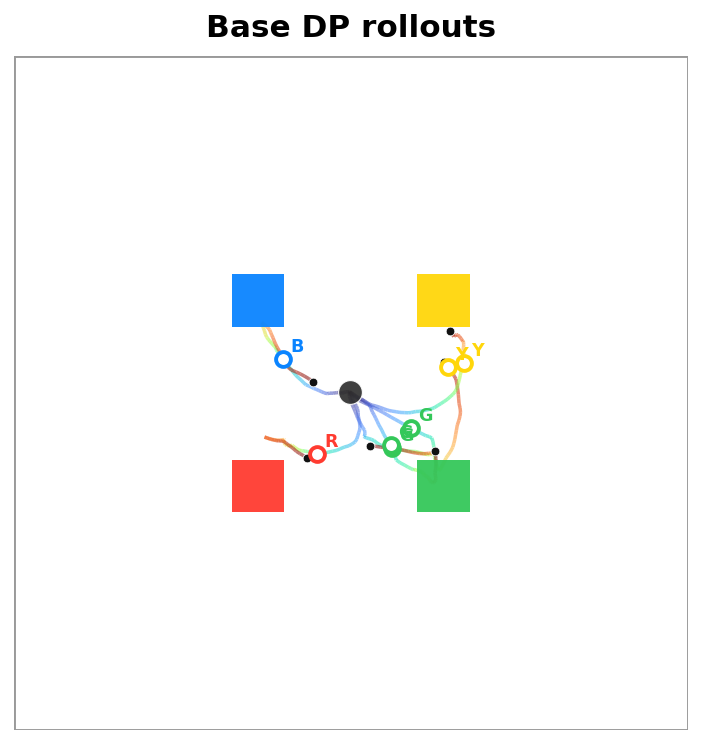

base DP hit counts: {'blue': 3, 'red': 1, 'green': 6, 'yellow': 4}


In [2]:
BASE_ROLLOUT_IDS = [0, 1, 2, 3, 4, 5]
MAX_BASE_STEPS = 70
base_root = RESULT_ROOT / 'base_dp_rollouts'
base_summary = load_json(base_root / 'summary.json')
setup_state = np.load(base_root / 'rollout_000' / 'setup_state.npy')

fig, ax = plt.subplots(figsize=(5.2, 5.2), constrained_layout=True)
style_env_axis(ax, setup_state, 'Base DP rollouts')

for rollout_idx in BASE_ROLLOUT_IDS:
    run_dir = base_root / f'rollout_{rollout_idx:03d}'
    traj = load_trajectory(run_dir)[:MAX_BASE_STEPS + 1]
    plot_progress_path(ax, traj, alpha=0.54, linewidth=1.8)
    summary = load_json(run_dir / 'rollout_summary.json')
    for block, step in summary.get('first_hits', {}).items():
        step = int(step)
        if step <= MAX_BASE_STEPS and step < len(traj):
            pos = traj[step]
            ax.scatter([pos[0]], [pos[1]], s=58, facecolors='white', edgecolors=BLOCK_COLORS[block], linewidths=2.0, zorder=8)
            ax.text(pos[0] + 0.022, pos[1] + 0.022, block[0].upper(), color=BLOCK_COLORS[block], fontsize=9, fontweight='bold', zorder=9)

fig.savefig(PLOT_DIR / 'fig1_base_dp_layout_rollouts.png', bbox_inches='tight')
plt.show()
print('base DP hit counts:', base_summary['hit_counts'])

## 2. Success Rate Over LTL Prefix Horizon

This plot uses actual success from the rollout summaries and imagined LTLDoG success from `diagnostics_ltldog_imagined_vs_actual/combined_success_summary.csv`.

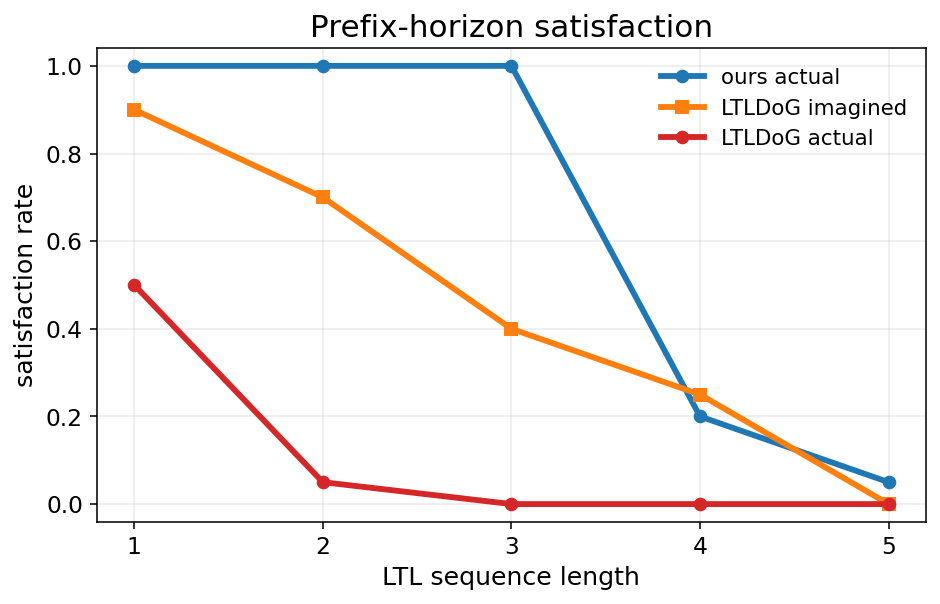

1 ours 1.0 ltldog imagined 0.9 ltldog actual 0.5
2 ours 1.0 ltldog imagined 0.7 ltldog actual 0.05
3 ours 1.0 ltldog imagined 0.4 ltldog actual 0.0
4 ours 0.2 ltldog imagined 0.25 ltldog actual 0.0
5 ours 0.05 ltldog imagined 0.0 ltldog actual 0.0


In [3]:
diag = load_diagnostic_success()
ours_summaries = all_method_summaries('ours')
ltldog_summaries = all_method_summaries(LTLDOG_METHOD)
horizons = sorted({int(s['ltl_horizon']) for s in ours_summaries + ltldog_summaries})

ours_actual = {int(s['ltl_horizon']): float(s['success_rate']) for s in ours_summaries}
ltldog_actual = {int(s['ltl_horizon']): float(s['success_rate']) for s in ltldog_summaries}
ltldog_imagined = {
    h: diag.get(h, {}).get('ltldog_imagined_generated_blocks', diag.get(h, {}).get('ltldog_imagined_success', np.nan))
    for h in horizons
}

fig, ax = plt.subplots(figsize=(6.6, 4.2), constrained_layout=True)
ax.plot(horizons, [ours_actual.get(h, np.nan) for h in horizons], marker='o', linewidth=3.0, color=METHOD_COLORS['ours'], label='ours actual')
ax.plot(horizons, [ltldog_imagined.get(h, np.nan) for h in horizons], marker='s', linewidth=3.0, color=METHOD_COLORS['ltldog_imagined'], label='LTLDoG imagined')
ax.plot(horizons, [ltldog_actual.get(h, np.nan) for h in horizons], marker='o', linewidth=3.0, color=METHOD_COLORS['ltldog_actual'], label='LTLDoG actual')
ax.set_title('Prefix-horizon satisfaction')
ax.set_xlabel('LTL sequence length')
ax.set_ylabel('satisfaction rate')
ax.set_xticks(horizons)
ax.set_ylim(-0.04, 1.04)
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)
fig.savefig(PLOT_DIR / 'fig2_success_rate_over_horizon.png', bbox_inches='tight')
plt.show()

for h in horizons:
    print(h, 'ours', ours_actual.get(h), 'ltldog imagined', ltldog_imagined.get(h), 'ltldog actual', ltldog_actual.get(h))

## 3. Environment Steps Taken Over Rollouts

Filled markers are completed rollouts; open markers are failures that exhausted the budget.

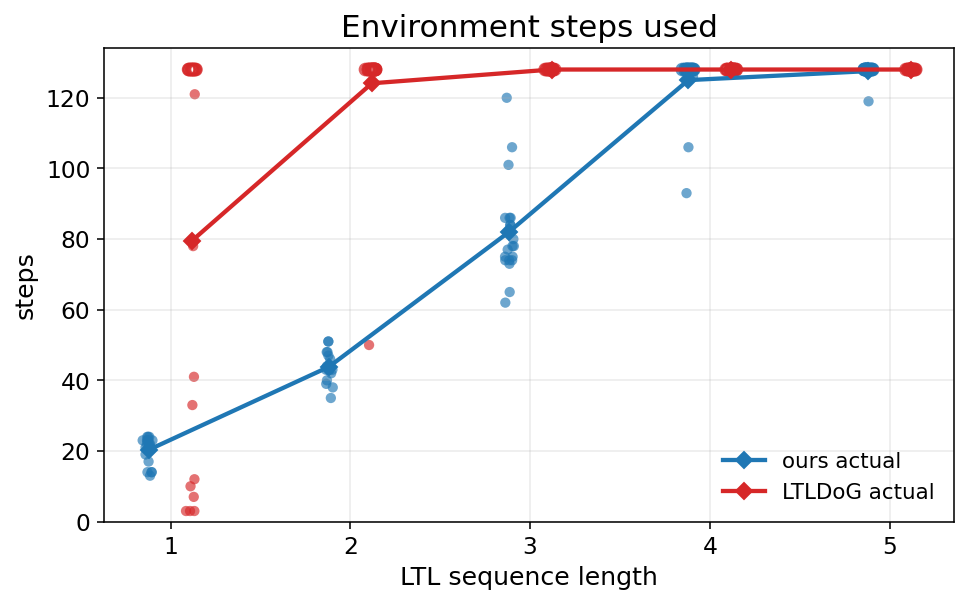

In [4]:
rows = collect_step_records()
horizons = sorted({row['horizon'] for row in rows})
method_offsets = {'ours': -0.12, 'ltldog': 0.12}
method_labels = {'ours': 'ours actual', 'ltldog': 'LTLDoG actual'}
method_colors = {'ours': METHOD_COLORS['ours'], 'ltldog': METHOD_COLORS['ltldog_actual']}

fig, ax = plt.subplots(figsize=(6.8, 4.2), constrained_layout=True)
rng = np.random.default_rng(0)
for method in ['ours', 'ltldog']:
    means_x, means_y = [], []
    for h in horizons:
        vals = [row for row in rows if row['method'] == method and row['horizon'] == h]
        if not vals:
            continue
        xs = h + method_offsets[method] + rng.normal(0.0, 0.015, size=len(vals))
        ys = [row['steps'] for row in vals]
        completed = np.array([row['complete'] for row in vals], dtype=bool)
        ax.scatter(np.asarray(xs)[completed], np.asarray(ys)[completed], s=28, color=method_colors[method], alpha=0.65, edgecolors='none')
        ax.scatter(np.asarray(xs)[~completed], np.asarray(ys)[~completed], s=34, facecolors='none', edgecolors=method_colors[method], alpha=0.75, linewidths=1.2)
        means_x.append(h + method_offsets[method])
        means_y.append(float(np.mean(ys)))
    ax.plot(means_x, means_y, marker='D', linewidth=2.2, color=method_colors[method], label=method_labels[method])

ax.set_title('Environment steps used')
ax.set_xlabel('LTL sequence length')
ax.set_ylabel('steps')
ax.set_xticks(horizons)
ax.set_ylim(0, 134)
ax.grid(True, alpha=0.25)
ax.legend(frameon=False)
fig.savefig(PLOT_DIR / 'fig3_steps_taken_over_horizon.png', bbox_inches='tight')
plt.show()

## 4. Example Rollouts

Left: a successful full-execution LTLDoG rollout for `blue -> yellow`. Right: a successful four-step rollout from our method. The code picks the first successful rollout by default, but the indices are printed so you can swap examples easily.

LTLDoG H2 example: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG/horizon_02_blue_yellow/ltldog_h128_compact_full_exec_tau0p001_scale0p10_g20/rollout_010
Ours H4 example: /home/moritz/src/guided-diffusion/outputs/toy_squares_rollouts/baseline_ltldog/rollouts/paper_test/main_result_LTLDOG/horizon_04_blue_yellow_green_red/ours/rollout_002


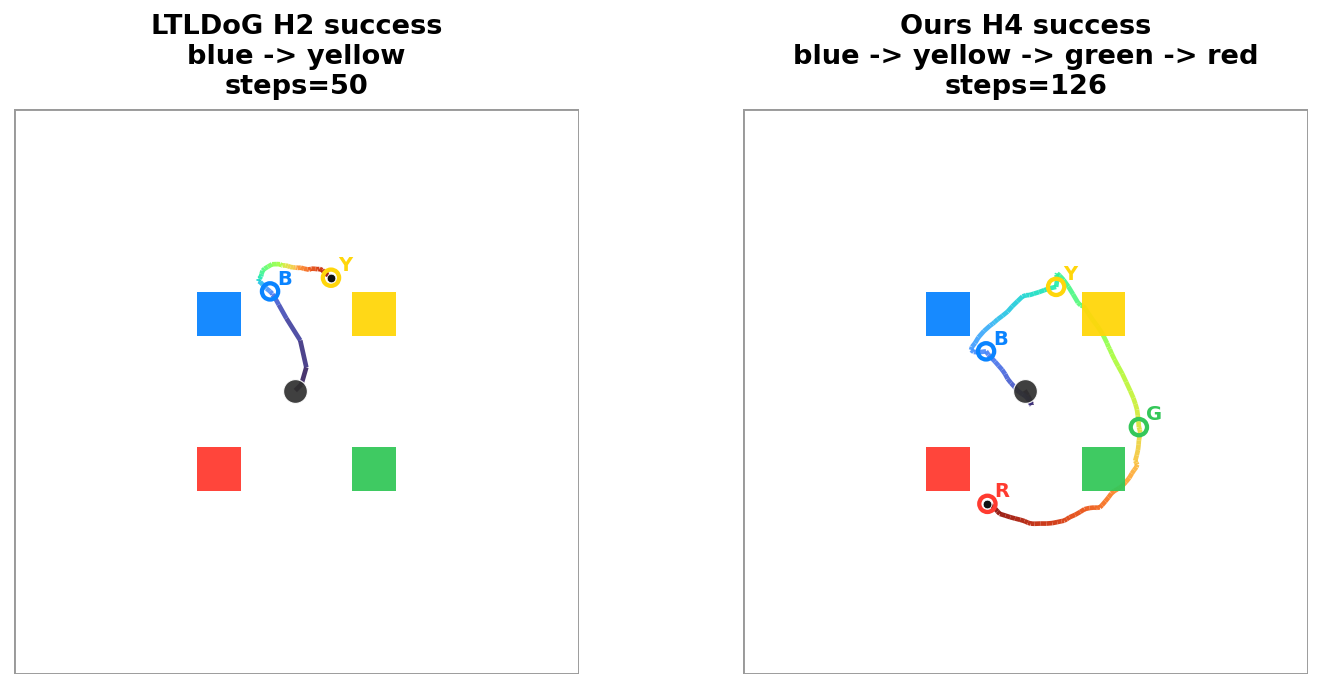

In [5]:
ltldog_h2 = method_summary(LTLDOG_METHOD, 2)
ours_h4 = method_summary('ours', 4)
ltldog_success = next(record for record in ltldog_h2['records'] if record['complete'])
ours_success = next(record for record in ours_h4['records'] if record['complete'])
ltldog_run = record_run_dir(ltldog_h2, ltldog_success)
ours_run = record_run_dir(ours_h4, ours_success)
print('LTLDoG H2 example:', ltldog_run)
print('Ours H4 example:', ours_run)

examples = [
    ('LTLDoG H2 success\nblue -> yellow', ltldog_run, ltldog_h2),
    ('Ours H4 success\nblue -> yellow -> green -> red', ours_run, ours_h4),
]

fig, axes = plt.subplots(1, 2, figsize=(10.4, 4.8), constrained_layout=True)
for ax, (title, run_dir, method_sum) in zip(axes, examples):
    setup_state = np.load(run_dir / 'setup_state.npy')
    rollout_summary = load_json(run_dir / 'rollout_summary.json')
    trajectory = load_trajectory(run_dir)
    style_env_axis(ax, setup_state, title)
    plot_progress_path(ax, trajectory, alpha=0.9, linewidth=2.4)
    mark_reaches(ax, run_dir, rollout_summary, label_text=True)
    ax.set_title(f"{title}\nsteps={rollout_summary['steps']}", fontweight='bold', fontsize=14, pad=8)

fig.savefig(PLOT_DIR / 'fig4_example_success_rollouts.png', bbox_inches='tight')
plt.show()